# Importing

In [3]:
# Import packages
import random
import numpy as np
from keras.src.metrics import F1Score
from numpy.typing import NDArray
from typing import List, Dict, Any, Generator
import time
import math
import pandas as pd
import matplotlib.pyplot as plt

2025-08-25 10:49:27.047173: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-25 10:49:27.503799: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-25 10:49:29.998789: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [4]:
import tensorflow as tf
from tensorflow import Tensor

# List available physical devices
physical_devices = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(physical_devices))

# If GPUs are found, check if TensorFlow is built with CUDA/ROCm support
if len(physical_devices) > 0:
    print("TensorFlow is built with GPU support:", tf.test.is_built_with_cuda())

Num GPUs Available:  0


2025-08-25 10:49:31.442262: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


# Fastest Confusion Matrix Generation So Far

In [5]:
def generate_confusion_matrix(actual: List | NDArray, predicted: List) -> Tensor | NDArray:
    assert len(actual) == len(predicted)

    # Convert inputs to tensors immediately (prevent slowdown from multiple conversions)
    actual_tensor = tf.cast(tf.constant(actual, dtype=tf.int32), tf.bool)
    predicted_tensor = tf.cast(tf.constant(predicted, dtype=tf.int32), tf.bool)

    sample_size = len(actual)

    predicted_positives = tf.math.count_nonzero(predicted_tensor)
    actual_positives = tf.math.count_nonzero(actual_tensor)

    true_positive = tf.math.count_nonzero(tf.logical_and(actual_tensor, predicted_tensor))
    false_positive = predicted_positives - true_positive
    false_negative = actual_positives - true_positive
    true_negative =  sample_size - true_positive - false_positive - false_negative

    confusion_matrix = tf.convert_to_tensor([[true_negative, false_positive],
                                         [false_negative, true_positive]])
    return confusion_matrix

In [6]:
# An implementation of computing the confusion matrix in parallel, using counting
def generate_confusion_matrices(actual : List | NDArray, predicted_matrix : List | NDArray) -> NDArray:
    assert len(actual) == len(predicted_matrix[0])

    # Convert inputs to tensors immediately (prevent slowdown from multiple conversions)
    actual_tensor = tf.cast(tf.constant(actual), tf.bool)
    predicted_tensor = tf.cast(tf.constant(predicted_matrix), tf.bool)

    sample_size = len(actual)

    predicted_positives = tf.math.count_nonzero(predicted_tensor, axis=1)
    actual_positives = tf.math.count_nonzero(actual_tensor)

    true_positive = tf.math.count_nonzero(tf.logical_and(actual_tensor, predicted_tensor), axis=1)
    false_positive = predicted_positives - true_positive
    false_negative = actual_positives - true_positive
    true_negative =  sample_size - true_positive - false_positive - false_negative

    confusion_matrix = tf.stack([
        tf.stack([true_negative, false_positive], axis=1),
        tf.stack([false_negative, true_positive], axis=1)
    ], axis=1)

    return confusion_matrix

In [7]:
def true_positive_rates(actual : List | NDArray, predicted_matrix : List | NDArray) -> float | Tensor:
    assert len(actual) == len(predicted_matrix[0])
    confusion_matrix = generate_confusion_matrices(actual, predicted_matrix)
    return confusion_matrix[:, 1, 1] / tf.reduce_sum(confusion_matrix[:, 1, :], axis=1)

In [8]:
def false_positive_rates(actual : List | NDArray, predicted_matrix : List | NDArray) -> float | Tensor:
    assert len(actual) == len(predicted_matrix[0])
    confusion_matrix = generate_confusion_matrices(actual, predicted_matrix)
    return confusion_matrix[:, 0, 1] / tf.reduce_sum(confusion_matrix[:, 0, :], axis=1)

In [9]:
thresholds = [0, 0.1666, 0.3333, 0.5, 0.6666, 0.8333, 1]
# Generating a more skilled distribution, as to get a better example of all metrics working, including AUROC
handpicked_data_set =          [1, 1, 1, 0, 0, 0, 0, 0, 0, 0]*1000
handpicked_model_predictions = [1, 0, 1, 1, 1, 1, 0, 0, 0, 0]*1000
handpicked_model_confidences = [0.9, 0.4, 0.8, 0.7, 0.6, 0.5, 0.3, 0.2, 0.1, 0]*1000

In [12]:
from keras.src import ops
def auroc(actual : List | NDArray, confidences : List | NDArray, thresholds : List | NDArray) -> Dict[str , NDArray| float]:
    assert len(actual) == len(confidences)

    actual = ops.convert_to_tensor(actual)
    confidences = ops.convert_to_tensor(confidences)
    thresholds = ops.convert_to_tensor(thresholds)

    predictions_per_threshold = tf.greater_equal(confidences, tf.reshape(thresholds, (-1, 1)))

    tprs = true_positive_rates(actual, predictions_per_threshold)
    fprs = false_positive_rates(actual, predictions_per_threshold)

    area = 0

    for i in range(len(tprs) - 1):
        width = fprs[i + 1] - fprs[i]
        height = (tprs[i + 1] + tprs[i]) / 2
        area += width.numpy() * height.numpy()
    return {
        "value" : -area,
        "tprs" : tprs,
        "fprs" : fprs
    }

0.8333333333333333


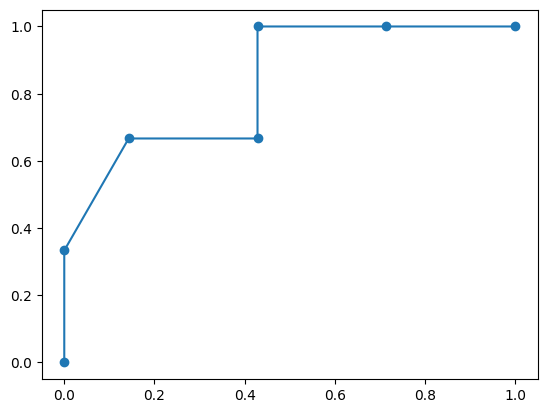

In [13]:
skilled = auroc(handpicked_data_set, handpicked_model_confidences, thresholds)
print(skilled["value"])
plt.plot(skilled["fprs"], skilled["tprs"], marker="o")

0.5005509544984537


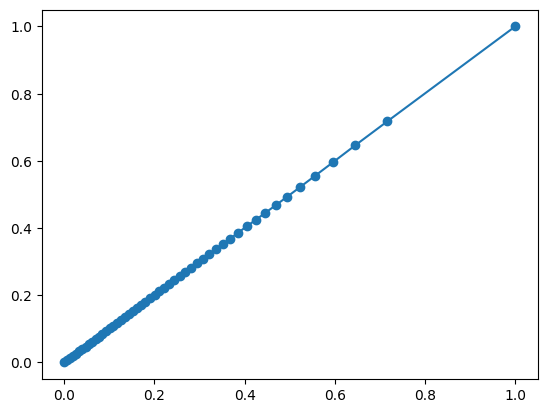

In [14]:
# Generate random positive/negative lists representing the dataset and model predictions
DATA_SIZE = 10000000
DATA_PERCENT_POSITIVE = 0.01
MODEL_PERCENT_POSITIVE = 0.2

data_set = [1 if random.random() < DATA_PERCENT_POSITIVE else 0 for x in range(DATA_SIZE)]

# Assuming uniform distribution from random.random(), using the below equation should result in a distribution that
# should maintain the desired positive/negative split for model predictions at a threshold of 0.5
confidence_exponent = math.log(0.5)/math.log(1 - MODEL_PERCENT_POSITIVE)
model_confidences = [random.random()**confidence_exponent for x in range(DATA_SIZE)]
model_predictions = [1 if model_confidences[x] > 0.5 else 0 for x in range(DATA_SIZE)]

unskilled = auroc(data_set, model_confidences, [0.02*i for i in range(51)])
print(unskilled["value"])
plt.plot(unskilled["fprs"], unskilled["tprs"], marker="o")

# Better Handpicked Data: 3% TP/1% FN/2% FP/94% TN Split

In [15]:
# Generating a more skilled distribution, as to get a better example of all metrics working, including AUROC
better_handpicked_data_set =          [1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                                       0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                                       0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                                       0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                                       0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                                       0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                                       0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                                       0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                                       0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                                       0, 0, 0, 0, 0, 0, 0, 0, 0, 0]*10000
better_handpicked_model_predictions = [1, 1, 1, 0, 1, 1, 0, 0, 0, 0,
                                       0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                                       0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                                       0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                                       0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                                       0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                                       0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                                       0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                                       0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                                       0, 0, 0, 0, 0, 0, 0, 0, 0, 0]*10000
better_handpicked_model_confidences = []
for i in range(10000):
    better_handpicked_model_confidences += [.5 + random.random()*.5, .5 + random.random()*.5, .5 + random.random()*.5, .5 + random.random()*.5,
                                            .5 + random.random()*.5, .5 + random.random()*.5, .5 + random.random()*.5,
                                            .5 + random.random()*.5, .5 + random.random()*.5, .5 + random.random()*.5,
                                            0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                                            0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19,
                                            0.2, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29,
                                            0.2, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29,
                                            0.3, 0.31, 0.32, 0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39,
                                            0.3, 0.31, 0.32, 0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39,
                                            0.4, 0.41, 0.42, 0.43, 0.44, 0.45, 0.46, 0.47, 0.48, 0.49,
                                            0.4, 0.41, 0.42, 0.43, 0.44, 0.45, 0.46, 0.47, 0.48, 0.49,
                                            0.4, 0.41, 0.42, 0.43, 0.44, 0.45, 0.46, 0.47, 0.48, 0.49]

0.9687087176562501


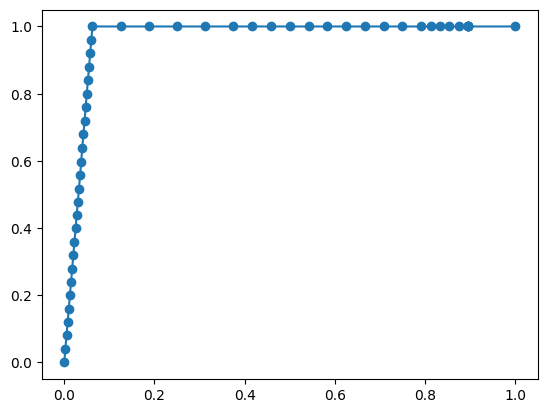

In [16]:
better_thresholds = [0.02*i for i in range(51)]
skilled = auroc(better_handpicked_data_set, better_handpicked_model_confidences, better_thresholds)
print(skilled["value"])
plt.plot(skilled["fprs"], skilled["tprs"], marker="o")

In [17]:
from typing_extensions import Self

class ConfusionMatrix:
    def __init__(self, true_positives : int, false_positives : int, false_negatives : int, true_negatives : int) -> None:
        self._true_positives = true_positives
        self._false_positives = false_positives
        self._false_negatives = false_negatives
        self._true_negatives = true_negatives

    def tp(self) -> int:
        return self._true_positives
    def fp(self) -> int:
        return self._false_positives
    def tn(self) -> int:
        return self._true_negatives
    def fn(self) -> int:
        return self._false_negatives

    @classmethod
    def generate(cls, actual : List | NDArray, predicted : List | NDArray) -> Self:
        assert len(actual) == len(predicted)

        # Convert inputs to tensors immediately (prevent slowdown from multiple conversions)
        actual_tensor = ops.cast(ops.convert_to_tensor(actual), tf.bool)
        predicted_tensor = ops.cast(ops.convert_to_tensor(predicted), tf.bool)

        sample_size = len(actual)

        predicted_positives = tf.math.count_nonzero(predicted_tensor)
        actual_positives = tf.math.count_nonzero(actual_tensor)

        true_positive = tf.math.count_nonzero(tf.logical_and(actual_tensor, predicted_tensor))
        false_positive = predicted_positives - true_positive
        false_negative = actual_positives - true_positive
        true_negative =  sample_size - true_positive - false_positive - false_negative

        confusion_matrix = cls(true_positive, false_positive, false_negative, true_negative)
        return confusion_matrix

    @classmethod
    def generate_from_thresholds(cls, actual : List | NDArray, confidences : List | NDArray, thresholds : List | NDArray) -> Self:
        assert len(actual) == len(confidences)

        # Convert inputs to tensors immediately (prevent slowdown from multiple conversions)
        actual_tensor = ops.cast(ops.convert_to_tensor(actual), tf.bool)
        confidence_tensor = ops.convert_to_tensor(confidences)
        threshold_tensor = tf.reshape(ops.convert_to_tensor(thresholds), (-1, 1))

        prediction_matrix = tf.greater_equal(confidence_tensor, threshold_tensor)

        sample_size = len(actual)

        predicted_positives = tf.math.count_nonzero(prediction_matrix, axis=1)
        actual_positives = tf.math.count_nonzero(actual_tensor)

        true_positive = tf.math.count_nonzero(tf.logical_and(actual_tensor, prediction_matrix), axis=1)
        false_positive = predicted_positives - true_positive
        false_negative = actual_positives - true_positive
        true_negative =  sample_size - true_positive - false_positive - false_negative

        return cls(true_positive, false_positive, false_negative, true_negative)



In [18]:
from keras.src import ops
from typing_extensions import Self
EPSILON = tf.constant(1e-7, dtype=tf.float64)

class F1Score:
    def __init__(self, threshold: float = 0.5, name: str = 'f1_score') -> None:
        self._threshold = threshold
        self._name = name
        self._confusion_matrix : ConfusionMatrix | None = None

    def update_state(self, y_true, y_pred) -> None:
        y_true = ops.convert_to_tensor(y_true)
        y_pred = ops.convert_to_tensor(y_pred)
        self._confusion_matrix = ConfusionMatrix.generate(y_true, y_pred)

    def result(self) -> float:
        if self._confusion_matrix is None:
            raise RuntimeError(f'F1Score object must first be updated with actual and predicted values before result can be retrieved')
        return 2* tf.cast(self._confusion_matrix.tp(), tf.float64) / (
                tf.cast(2* self._confusion_matrix.tp() + self._confusion_matrix.fp() + self._confusion_matrix.fn(), tf.float64) + EPSILON
        )

    def __call__(self, *args, **kwargs) -> float:
        self.update_state(*args, **kwargs)
        return self.result()

    @classmethod
    def from_config(cls, config: dict) -> Self:
        return cls(**config)

    def get_config(self) -> dict:
        return {
            "threshold": self._threshold,
            "name": self._name,
        }

In [19]:
from keras.src import ops
from typing_extensions import Self
EPSILON = tf.constant(1e-7, dtype=tf.float64)

class AUC:
    def __init__(self, thresholds: List | NDArray = 0.5, name: str = None, curve : str = 'ROC') -> None:
        self._thresholds = thresholds
        self._name = name
        self._confusion_matrix : ConfusionMatrix | None = None
        self._curve = curve

    def update_state(self, y_true, y_pred) -> None:
        y_true = ops.convert_to_tensor(y_true)
        y_pred = ops.convert_to_tensor(y_pred)
        self._confusion_matrix = ConfusionMatrix.generate_from_thresholds(y_true, y_pred, self._thresholds)

    def result(self) -> float:
        if self._confusion_matrix is None:
            raise RuntimeError(f'AUC object must first be updated with actual and confidence values before result can be retrieved')

        tprs = ops.cast(self._confusion_matrix.tp(), tf.float64) / ops.cast(ops.add(self._confusion_matrix.tp(), self._confusion_matrix.fn()), tf.float64) + EPSILON
        fprs = ops.cast(self._confusion_matrix.fp(), tf.float64) / ops.cast(ops.add(self._confusion_matrix.fp(), self._confusion_matrix.tn()),tf.float64) + EPSILON

        delta_x   = fprs[:-1] - fprs[1:]
        average_heights = 0.5 * (tprs[:-1] + tprs[1:])
        return tf.reduce_sum(average_heights * delta_x)

    def __call__(self, *args, **kwargs) -> float:
        self.update_state(*args, **kwargs)
        return self.result()

    @classmethod
    def from_config(cls, config: dict) -> Self:
        return cls(**config)

    def get_config(self) -> dict:
        return {
            "thresholds": self._thresholds,
            "name": self._name,
        }

In [20]:
# Built-in TensorFlow implementation for F1 score from actuals and predictions
metric = tf.keras.metrics.F1Score(threshold=0.5)
data_tensor = tf.reshape(tf.constant(data_set), (-1, 1))
confidence_tensor = tf.reshape(tf.constant(model_confidences), (-1, 1))
start = time.time()
metric.update_state(data_tensor, confidence_tensor)
end = time.time()
print(metric.result().numpy()[0])
print(f"Computation time: {end - start:.4} s")

0.019191574
Computation time: 0.06376 s


In [21]:
metric = F1Score(threshold=0.5)
data_tensor = tf.constant(data_set)
confidence_tensor = tf.constant(model_predictions)
start = time.time()
metric.update_state(data_tensor, confidence_tensor)
end = time.time()
print(metric.result().numpy())
print(f"Computation time: {end - start:.4} s")

0.019191582308802864
Computation time: 0.02238 s


# F1 Comparison

In [72]:
data = {
    "Method Name": [],
    "Run Time (seconds)" : []
}

run_times = []
result = None
# Custom Implementation Test
for i in range(20):
    metric = F1Score(threshold=0.5)
    data_tensor = tf.reshape(tf.constant(better_handpicked_data_set), (-1, 1))
    confidence_tensor = tf.reshape(tf.constant(better_handpicked_model_confidences), (-1, 1))
    start = time.time()
    metric.update_state(data_tensor, confidence_tensor)
    end = time.time()
    run_times.append(end - start)
average = sum(run_times) / len(run_times)
data["Method Name"].append("Custom Implementation")
data["Run Time (seconds)"].append(average)

run_times = []
# TensorFlow Implementation Test
for i in range(20):
    metric = tf.keras.metrics.F1Score(threshold=0.5)
    data_tensor = tf.reshape(tf.constant(better_handpicked_data_set), (-1, 1))
    confidence_tensor = tf.reshape(tf.constant(better_handpicked_model_confidences), (-1, 1))
    start = time.time()
    metric.update_state(data_tensor, confidence_tensor)
    end = time.time()
    run_times.append(end - start)
average = sum(run_times) / len(run_times)
data["Method Name"].append("TensorFlow")
data["Run Time (seconds)"].append(average)

table = pd.DataFrame(data)
print(table)

             Method Name  Run Time (seconds)
0  Custom Implementation            0.005205
1             TensorFlow            0.009173


# AUROC comparison

In [73]:
data = {
    "Method Name": [],
    "Run Time (seconds)" : []
}

run_times = []
result = None
# Custom Implementation Test
for i in range(20):
    metric = AUC(thresholds=better_thresholds)
    start = time.time()
    metric.update_state(better_handpicked_data_set, better_handpicked_model_confidences)
    result = metric.result()
    end = time.time()
    run_times.append(end - start)
average = sum(run_times) / len(run_times)
data["Method Name"].append("Custom Implementation")
data["Run Time (seconds)"].append(average)

run_times = []
# TensorFlow Implementation Test
for i in range(20):
    metric = tf.keras.metrics.AUC(thresholds=better_thresholds)
    start = time.time()
    metric.update_state(better_handpicked_data_set, better_handpicked_model_confidences)
    result = metric.result()
    end = time.time()
    run_times.append(end - start)
average = sum(run_times) / len(run_times)
data["Method Name"].append("TensorFlow")
data["Run Time (seconds)"].append(average)

table = pd.DataFrame(data)
print(table)

             Method Name  Run Time (seconds)
0  Custom Implementation            0.717366
1             TensorFlow            0.753958


# Stratified Sampling

In [24]:
from collections import defaultdict
from typing import Generator, Any

class StratifiedSampler:
    def __init__(self, x_data : List | NDArray | tf.Tensor,
                 y_data : List | NDArray | tf.Tensor = None,
                 sample_weight : List | NDArray | tf.Tensor = None,
                 training_percentage : float = None,
                 testing_percentage : float = None) -> None:

        if sample_weight is None:
            sample_weight = tf.ones(len(x_data))

        data_set = None

        if y_data is not None:
                data_set = tf.stack([x_data, y_data, sample_weight], axis=1)
        else:
            data_set = tf.stack([x_data[:, 0], x_data[:, 1], sample_weight], axis=1)

        if data_set is List:
            data_set = np.array(data_set)
        if data_set is not NDArray:
            data_set = data_set.numpy()

        data_set = data_set.tolist()
        assert 2 <= len(data_set[0]) <= 3

        self._training_percentage = training_percentage
        self._testing_percentage = testing_percentage
        if training_percentage is None:
            if testing_percentage is None:
                self._training_percentage = 0.8
                self._testing_percentage = 0.2
            else:
                self._training_percentage = 1 - testing_percentage
        else:
            if testing_percentage is None:
                self._testing_percentage = 1 - training_percentage

        groups = defaultdict(list)
        for x, y, z in data_set:
            groups[y].append((x, y, z))

        self._training_set = []
        self._testing_set = []

        for key in groups.keys():
            arr = groups[key]
            np.random.shuffle(arr)
            total = len(arr)
            train_split = round(total * self._training_percentage)
            self._training_set.extend(arr[:train_split])
            self._testing_set.extend(arr[train_split:])

        np.random.shuffle(self._training_set)
        np.random.shuffle(self._testing_set)

    def stratified_batches(self,
           desired_num_batches=0,
           desired_batch_size=0,
           sample_weights=None) -> tf.data.Dataset:
        # Ensure desired_batch_size
        if desired_num_batches == 0 and desired_batch_size == 0:
            raise RuntimeError("num_batches or batch_size must be specified")
        if desired_batch_size == 0:
            desired_batch_size = math.ceil(len(self._training_set) / desired_num_batches)

        # Group training data by class
        classes = defaultdict(list)
        for x, y, z in self._training_set:
            classes[y].append((x, y))

        # Calculate the number of classes per batch, given desired_batch_size
        class_per_batch = defaultdict(float)
        for key in classes.keys():
            class_per_batch[key] = math.ceil(desired_batch_size * len(classes[key]) / len(self._training_set))

        # print("Classes per batch:", class_per_batch)

        batches_required = 0
        for key in classes.keys():
            batches_required = max(batches_required, math.ceil(len(classes[key]) / class_per_batch[key]))

        even_classes = defaultdict(list)
        for key in classes.keys():
            # Create copy of current group sample list
            even_classes[key] = classes[key][:]

            # Calculate number of samples needed to have the expected number of samples in each batch
            samples_needed  = class_per_batch[key] * batches_required
            # Calculate discrepancy between current and desired amount of samples
            discrepancy = samples_needed - len(even_classes[key])
            # Double sample list as long as discrepancy is larger than length of sample list (oversampling)
            sample_multiplier = 1
            while len(even_classes[key]) < discrepancy:
                discrepancy -= len(classes[key])
                sample_multiplier += 1
                even_classes[key].extend(classes[key])
            if sample_weights is not None:
                sample_weights[key] /= sample_multiplier
            # Compensate for any additional discrepancy
            even_classes[key].extend(even_classes[key][:discrepancy])

        for key in even_classes.keys():
            print(key, len(even_classes[key]), len(even_classes[key])/class_per_batch[key])

        # Function that returns iterator that yields one batch at a time
        def compute_even_batches() -> Generator[int, Any, None]:
            total_weight_unnormalized = 0
            for key in even_classes.keys():
                if sample_weights is None:
                    total_weight_unnormalized += class_per_batch[key]
                else:
                    total_weight_unnormalized += class_per_batch[key] * sample_weights[key]

            for i in range(batches_required):
                batch = []
                batch_weights = []
                for key in even_classes.keys():
                    batch.extend(even_classes[key][i*class_per_batch[key]:(i+1)*class_per_batch[key]])
                    if sample_weights is None:
                        batch_weights.extend([1/total_weight_unnormalized]*class_per_batch[key])
                    else:
                        batch_weights.extend([sample_weights[key]/total_weight_unnormalized]*class_per_batch[key])

                batch_tensor = tf.constant(batch, dtype=tf.float32)
                batch_weight_tensor = tf.constant(batch_weights, dtype=tf.float32)
                combined_batch = tf.concat([batch_tensor, tf.expand_dims(batch_weight_tensor, axis=1)], axis=1)
                if i == 0:
                    print(combined_batch.numpy())

                yield combined_batch

        return tf.data.Dataset.from_generator(
            compute_even_batches,
            output_signature=(
                tf.TensorSpec(shape=(None,), dtype=tf.float32),
                tf.TensorSpec(shape=(None,), dtype=tf.float32),
                tf.TensorSpec(shape=(None,), dtype=tf.float32),
            )
        )

    def training_data(self) -> NDArray:
        return self._training_set

    def testing_data(self) -> NDArray:
        return self._testing_set




In [25]:
data = StratifiedSampler(better_handpicked_data_set, better_handpicked_data_set)

# print(len(data.training_data()))
# print(np.unique(data.training_data(), return_counts=True))
#
# print(len(data.testing_data()))
# print(np.unique(data.testing_data(), return_counts=True))

data.stratified_batches(desired_batch_size=10000, sample_weights={
    0: 1,
    1: 100
})

0.0 768000 80.0
1.0 32000 80.0


<_FlatMapDataset element_spec=(TensorSpec(shape=(None,), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>